# __Глубокое обучение__

## Тема 8.1. Нейронные сети для аппроксимации решений дифференциальных уравнений

<!--
План занятия:
– Дифференциальные уравнения
– Аппроксимация решений дифференциальных уравнений
- Машинное обучение на основе данных
- Машинное обучение на основе физики
Задание на дом:
– десять вариантов ОДУ с начальными условиями
-->



## Машинное обучение на основе данных (data driven machine learning)

В методах машинного обучения, основанных на данных, для прогнозирования решения уравнения в частных производных используется функция $\mathcal{F}$ для аппроксимации размеченных данных внутри области. Возьмем в качестве примера уравнение Бюргерса, чтобы проиллюстрировать использование методов, основанных на данных, для аппроксимации решения.

\begin{align}
&u_t + \nu_1uu_x -\nu_2 u_{xx} = 0, \quad  x\in [-1,1], t\in[0, 1] \\
&u(x,0) = -\sin(\pi x), \quad  x\in [-1,1]\\
&u(-1,t) = u(1,t) = 0, \quad t\in [0,1]
\end{align}
где $\nu_1,\nu_2$ — параметры уравнения в частных производных (здесь $\nu_1=1$ и $\nu_2=0.005$).

Обозначим через $\hat{u}=\mathcal{F}(\boldsymbol{\mathrm{x}}, t, \boldsymbol{\theta})$ прогноз решения при помощи методов, основанных на данных. В качестве функции потерь выбирается отклонение между прогнозом и размеченными данными:
\begin{equation*}
L = \dfrac{1}{N_{data}}\sum_{i=1}^{N_{data}}(|u(x^i,t^i)-\hat{u}(x^i,t^i)|^2)
\end{equation*}

#### Загрузка пакетов

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
from keras.layers import Input,Dense
from keras.optimizers import Adam
keras.__version__

'3.9.2'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from math import *
import tensorflow as tf
import sys
tf.__version__

'2.18.0'

#### Определяем область

In [3]:
# определение области

nx = 256
nt = 100
x = np.linspace(-1, 1, nx)
t = np.linspace(0, 1, nt)
X, T = np.meshgrid(x,t)

X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
X_star.shape

(25600, 2)

In [4]:
# точное решение
u_star_array = np.load('./burgers_sol.npy', allow_pickle=True)
u_star = u_star_array[20]
u_star.shape

(25600, 1)

#### Определяем набор обучающих точек

In [5]:
# определяем обучающие точки
N_data = 1000
idx_Xdata = np.random.choice(X_star.shape[0], N_data, replace=False)
X_data = X_star[idx_Xdata]
u_data = u_star[idx_Xdata]
X_data.shape, u_data.shape

((1000, 2), (1000, 1))

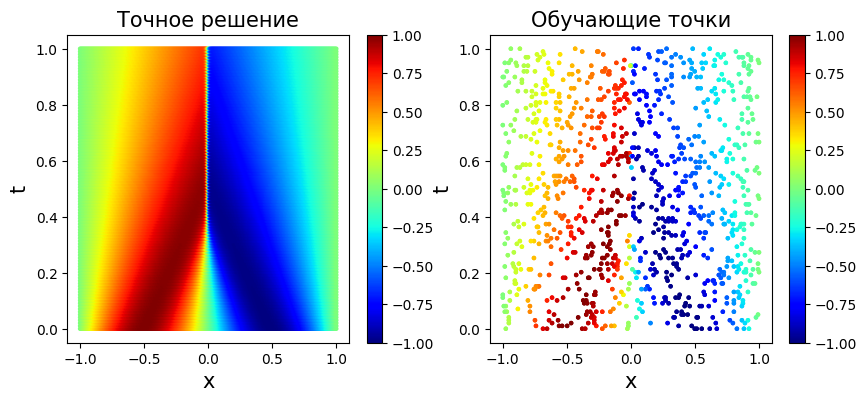

In [6]:
fig = plt.figure(figsize=[10,4])
axes = fig.subplots(1,2, sharex=False, sharey=False)
img1 = axes[0].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Точное решение', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
plt.colorbar(img1, ax=axes[0])
img2 = axes[1].scatter(X_data[:, 0:1], X_data[:, 1:2], 
                       c=u_data, cmap='jet', vmax=1, vmin=-1, s=5)
axes[1].scatter(X_data[:, 0:1], X_data[:, 1:2], 
                c=u_data, cmap='jet', vmax=1, vmin=-1, s=5)
axes[1].set_title('Обучающие точки', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
plt.colorbar(img2, ax=axes[1]);

### 1. Регрессия на основе случайного леса <a name="1-bullet"></a>

In [7]:
from sklearn.ensemble import RandomForestRegressor

RF = RandomForestRegressor(max_depth=None, random_state=0, 
                           max_features=None, n_estimators=100)
RFfit=RF.fit(X_data, np.ravel(u_data))

u_data_pred_RF = RFfit.predict(X_data)
u_star_pred_RF = RFfit.predict(X_star)

# np.linalg.norm – норма матрицы (корень из суммы квадратов элементов)
print("Ошибка случайного леса на обучающих точках: ", 
      np.linalg.norm(u_data_pred_RF.flatten() - u_data.flatten())/\
      np.linalg.norm(u_data.flatten()))
print("Ошибка случайного леса на тестовых точках:  ", 
      np.linalg.norm(u_star_pred_RF.flatten() - u_star.flatten())/\
      np.linalg.norm(u_star.flatten()))

Ошибка случайного леса на обучающих точках:  0.02345802775655003
Ошибка случайного леса на тестовых точках:   0.06051675323744544


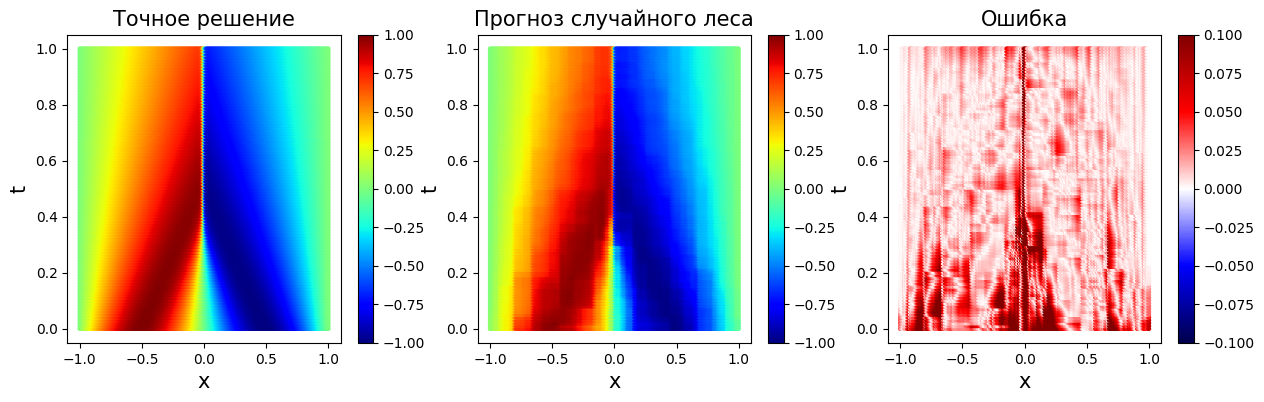

In [8]:
fig = plt.figure(figsize=[15,4])
axes = fig.subplots(1,3, sharex=False, sharey=False)
img1 = axes[0].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Точное решение', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
plt.colorbar(img1, ax=axes[0])
img2 = axes[1].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star_pred_RF, cmap='jet', 
                       vmax=1, vmin=-1, s=5)
axes[1].set_title('Прогноз случайного леса', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
plt.colorbar(img2, ax=axes[1])
img3 = axes[2].scatter(
    X_star[:, 0:1], X_star[:, 1:2], 
    c=np.abs(u_star.flatten()-u_star_pred_RF.flatten()), 
    cmap='seismic', vmax=0.1, vmin=-0.1, s=5
)
axes[2].set_title('Ошибка', fontsize=15)
axes[2].set_xlabel('x', fontsize=15)
axes[2].set_ylabel('t', fontsize=15)
plt.colorbar(img3, ax=axes[2]);

### 2. Регрессия на основе градиентного бустинга <a name="2-bullet"></a>

In [9]:
from sklearn.ensemble import GradientBoostingRegressor

GB = GradientBoostingRegressor(
    max_depth=None, random_state=0, max_features=None, n_estimators=200
)

GBfit = GB.fit(X_data, np.ravel(u_data))
GradientBoostingRegressor(random_state=0)

u_data_pred_GB = GB.predict(X_data)
u_star_pred_GB = GB.predict(X_star)

print("Ошибка градиентного бустинга на обучающих точках: ", 
      np.linalg.norm(u_data_pred_GB.flatten() - u_data.flatten())/\
      np.linalg.norm(u_data.flatten()))
print("Ошибка градиентного бустинга на тестовых точках:  ", 
      np.linalg.norm(u_star_pred_GB.flatten() - u_star.flatten())/\
      np.linalg.norm(u_star.flatten()))

Ошибка градиентного бустинга на обучающих точках:  2.418779413030869e-08
Ошибка градиентного бустинга на тестовых точках:   0.08570194303641447


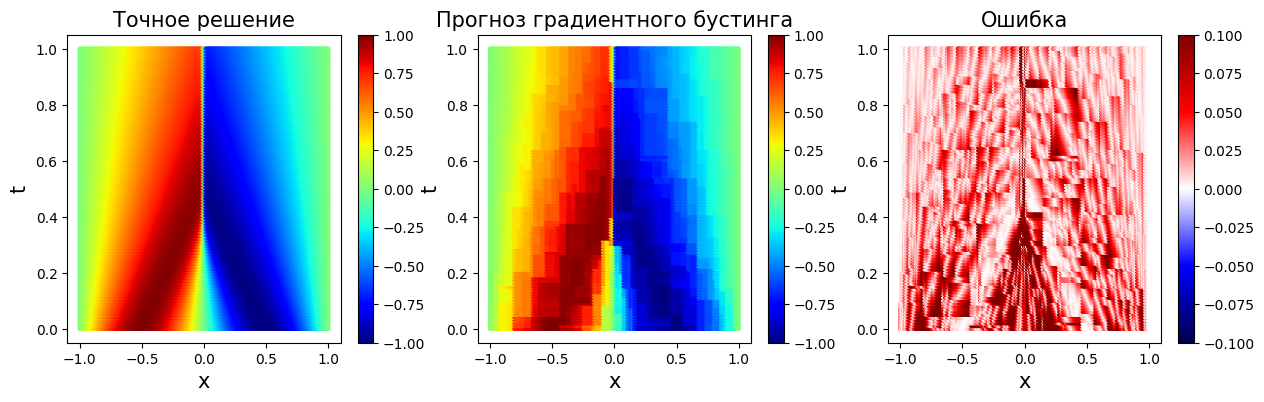

In [10]:
fig = plt.figure(figsize=[15,4])
axes = fig.subplots(1,3, sharex=False, sharey=False)
img1 = axes[0].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Точное решение', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
plt.colorbar(img1, ax=axes[0])
img2 = axes[1].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star_pred_GB, cmap='jet', 
                       vmax=1, vmin=-1, s=5)
axes[1].set_title('Прогноз градиентного бустинга', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
plt.colorbar(img2, ax=axes[1])
img3 = axes[2].scatter(
    X_star[:, 0:1], X_star[:, 1:2], 
    c=np.abs(u_star.flatten()-u_star_pred_GB.flatten()), 
    cmap='seismic', vmax=0.1, vmin=-0.1, s=5
)
axes[2].set_title('Ошибка', fontsize=15)
axes[2].set_xlabel('x', fontsize=15)
axes[2].set_ylabel('t', fontsize=15)
plt.colorbar(img3, ax=axes[2]);

### 3. Нейронные сети на основе данных (data-driven neural networks) <a name="3-bullet"></a>

In [11]:
layers = [2] + [50]*4 + [1]
layers

[2, 50, 50, 50, 50, 1]

In [12]:
NN = keras.Sequential()
NN.add(keras.layers.InputLayer(shape=(layers[0],)))
for i in range(1, len(layers) - 1):
    NN.add(keras.layers.Dense(layers[i], 
                              activation=keras.activations.tanh, 
                              kernel_initializer="glorot_normal"))
NN.add(keras.layers.Dense(layers[-1], activation=None, 
                          kernel_initializer="glorot_normal"))
NN.summary()

2025-12-10 11:25:17.235393: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2025-12-10 11:25:17.235414: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-12-10 11:25:17.235420: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
I0000 00:00:1765355117.236007 3931889 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1765355117.236051 3931889 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,851 (30.67 KB)

 Trainable params: 7,851 (30.67 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
NN.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3), 
    loss=keras.losses.MeanSquaredError()
)

In [14]:
%time NN.fit(X_data, u_data, epochs=200, verbose=0);

2025-12-10 11:25:17.633328: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


CPU times: user 56.9 s, sys: 38.6 s, total: 1min 35s
Wall time: 52.1 s


In [15]:
u_data_pred_NN = NN.predict(X_data)
u_star_pred_NN = NN.predict(X_star)

print("Ошибка нейронной сети на обучающих точках: ", 
      np.linalg.norm(u_data_pred_NN.flatten() - u_data.flatten())/\
      np.linalg.norm(u_data.flatten()))
print("Ошибка нейронной сети на тестовых точках:  ", 
      np.linalg.norm(u_star_pred_NN.flatten() - u_star.flatten())/\
      np.linalg.norm(u_star.flatten()))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Ошибка нейронной сети на обучающих точках:  0.03383341871892767
Ошибка нейронной сети на тестовых точках:   0.0374429740839113


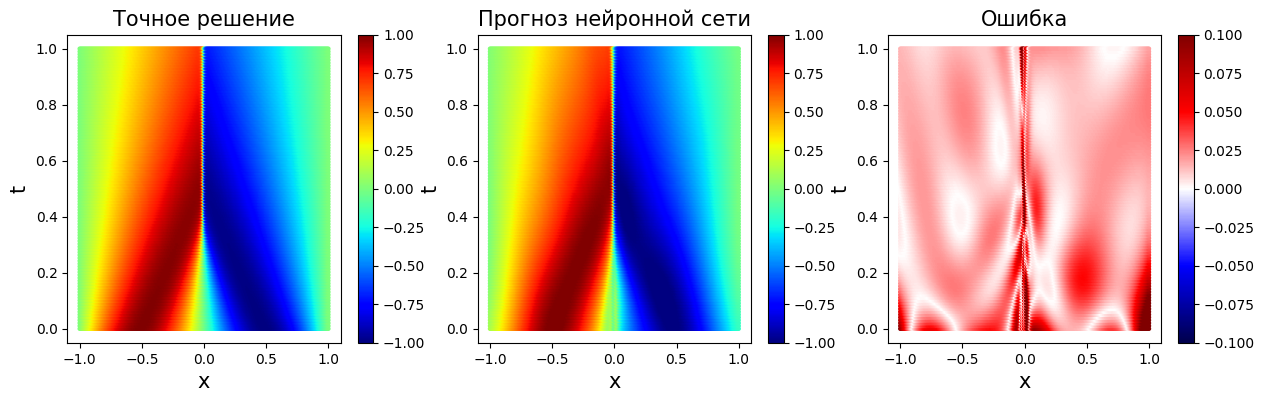

In [16]:
fig = plt.figure(figsize=[15,4])
axes = fig.subplots(1,3, sharex=False, sharey=False)
img1 = axes[0].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Точное решение', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
plt.colorbar(img1, ax=axes[0])
img2 = axes[1].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star_pred_NN, cmap='jet', 
                       vmax=1, vmin=-1, s=5)
axes[1].set_title('Прогноз нейронной сети', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
plt.colorbar(img2, ax=axes[1])
img3 = axes[2].scatter(
    X_star[:, 0:1], X_star[:, 1:2], 
    c=np.abs(u_star.flatten()-u_star_pred_NN.flatten()), 
    cmap='seismic', vmax=0.1, vmin=-0.1, s=5
)
axes[2].set_title('Ошибка', fontsize=15)
axes[2].set_xlabel('x', fontsize=15)
axes[2].set_ylabel('t', fontsize=15)
plt.colorbar(img3, ax=axes[2]);

## Что будет, если оставим только данные на границе?

#### Определим точки обучения

In [17]:
# определим начальные условия
idx_init = np.where(X_star[:, 1]==0)[0]
X_init = X_star[idx_init]
u_init = -np.sin(pi*X_init[:, 0:1])

# определим граничные условия
idx_bc = np.where((X_star[:, 0]==1.0)|(X_star[:, 0]==-1.0))[0]
X_bc = X_star[idx_bc]
u_bc = np.zeros((X_bc.shape[0], 1))

# определим обучающие точки
X_data = np.concatenate((X_init, X_bc), axis=0)
u_data = np.concatenate((u_init, u_bc), axis=0)
X_data.shape, u_data.shape

((456, 2), (456, 1))

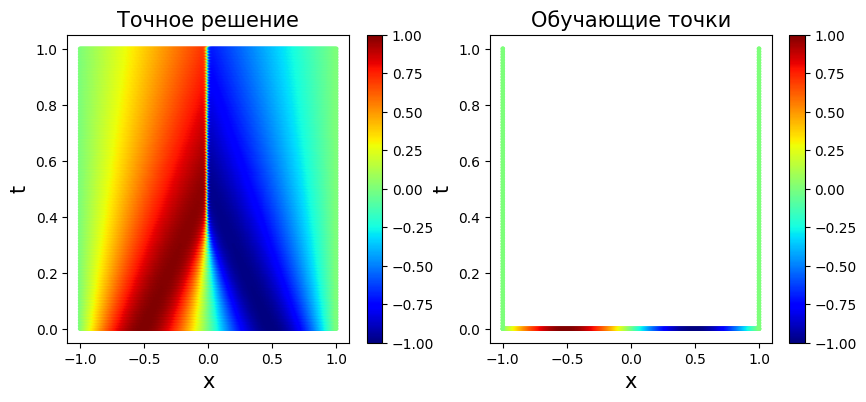

In [18]:
fig = plt.figure(figsize=[10,4])
axes = fig.subplots(1,2, sharex=False, sharey=False)
img1 = axes[0].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Точное решение', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
plt.colorbar(img1, ax=axes[0])
img2 = axes[1].scatter(X_data[:, 0:1], X_data[:, 1:2], 
                       c=u_data, cmap='jet', vmax=1, vmin=-1, s=5)
axes[1].scatter(X_data[:, 0:1], X_data[:, 1:2], c=u_data, 
                cmap='jet', vmax=1, vmin=-1, s=5)
axes[1].set_title('Обучающие точки', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
plt.colorbar(img2, ax=axes[1]);

In [19]:
# случайный лес
RF = RandomForestRegressor(
    max_depth=None, random_state=0, max_features=None, n_estimators=100
)
RFfit=RF.fit(X_data, np.ravel(u_data))

u_data_pred_RF = RFfit.predict(X_data)
u_star_pred_RF = RFfit.predict(X_star)

print("Ошибка случайного леса на обучающих точках: ", 
      np.linalg.norm(u_data_pred_RF.flatten() - u_data.flatten())/\
      np.linalg.norm(u_data.flatten()))
print("Ошибка случайного леса на тестовых точках:  ", 
      np.linalg.norm(u_star_pred_RF.flatten() - u_star.flatten())/\
      np.linalg.norm(u_star.flatten()))

Ошибка случайного леса на обучающих точках:  0.0050646671022096315
Ошибка случайного леса на тестовых точках:   0.5872864156659127


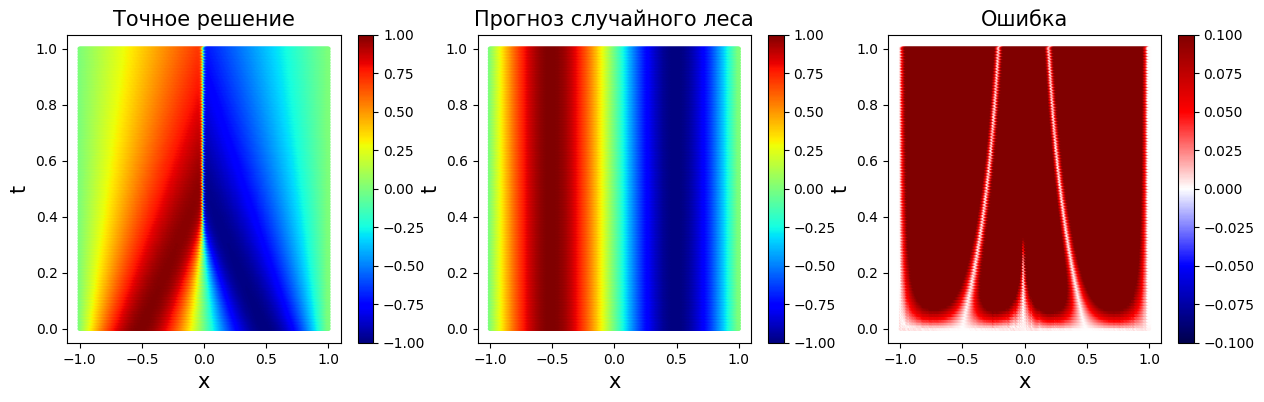

In [20]:
fig = plt.figure(figsize=[15,4])
axes = fig.subplots(1,3, sharex=False, sharey=False)
img1 = axes[0].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Точное решение', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
plt.colorbar(img1, ax=axes[0])
img2 = axes[1].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star_pred_RF, cmap='jet', 
                       vmax=1, vmin=-1, s=5)
axes[1].set_title('Прогноз случайного леса', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
plt.colorbar(img2, ax=axes[1])
img3 = axes[2].scatter(
    X_star[:, 0:1], X_star[:, 1:2], 
    c=np.abs(u_star.flatten()-u_star_pred_RF.flatten()), 
    cmap='seismic', vmax=0.1, vmin=-0.1, s=5
)
axes[2].set_title('Ошибка', fontsize=15)
axes[2].set_xlabel('x', fontsize=15)
axes[2].set_ylabel('t', fontsize=15)
plt.colorbar(img3, ax=axes[2]);

In [21]:
# градиентный бустинг
GB = GradientBoostingRegressor(max_depth=None, random_state=0, 
                               max_features=None, n_estimators=200)
GBfit = GB.fit(X_data, np.ravel(u_data))
GradientBoostingRegressor(random_state=0)

u_data_pred_GB = GB.predict(X_data)
u_star_pred_GB = GB.predict(X_star)

print("Ошибка градиентного бустинга на обучающих точках: ", 
      np.linalg.norm(u_data_pred_GB.flatten() - u_data.flatten())/\
      np.linalg.norm(u_data.flatten()))
print("Ошибка градиентного бустинга на тестовых точках:  ", 
      np.linalg.norm(u_star_pred_GB.flatten() - u_star.flatten())/\
      np.linalg.norm(u_star.flatten()))

Ошибка градиентного бустинга на обучающих точках:  2.7939815694966182e-08
Ошибка градиентного бустинга на тестовых точках:   0.5874745074829961


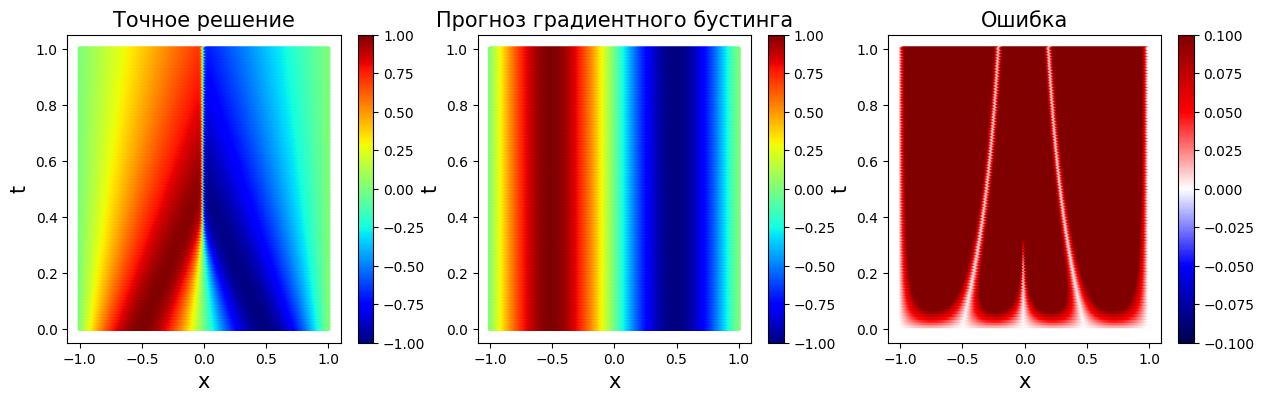

In [22]:
fig = plt.figure(figsize=[15,4])
axes = fig.subplots(1,3, sharex=False, sharey=False)
img1 = axes[0].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Точное решение', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
plt.colorbar(img1, ax=axes[0])
img2 = axes[1].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star_pred_GB, cmap='jet', 
                       vmax=1, vmin=-1, s=5)
axes[1].set_title('Прогноз градиентного бустинга', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
plt.colorbar(img2, ax=axes[1])
img3 = axes[2].scatter(
    X_star[:, 0:1], X_star[:, 1:2], 
    c=np.abs(u_star.flatten()-u_star_pred_GB.flatten()), 
    cmap='seismic', vmax=0.1, vmin=-0.1, s=5
)
axes[2].set_title('Ошибка', fontsize=15)
axes[2].set_xlabel('x', fontsize=15)
axes[2].set_ylabel('t', fontsize=15)
plt.colorbar(img3, ax=axes[2]);

In [23]:
layers = [2] + [50]*4 + [1]

NN = tf.keras.Sequential()
NN.add(tf.keras.layers.InputLayer(shape=(layers[0],)))
for i in range(1, len(layers) - 1):
    NN.add(tf.keras.layers.Dense(layers[i], 
                                 activation=tf.nn.tanh, 
                                 kernel_initializer="glorot_normal"))
NN.add(tf.keras.layers.Dense(layers[-1], activation=None, 
                             kernel_initializer="glorot_normal"))

NN.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=tf.keras.losses.MeanSquaredError())
NN.fit(X_data, u_data,epochs=200,verbose=0)

u_data_pred_NN = NN.predict(X_data)
u_star_pred_NN = NN.predict(X_star)

print("Ошибка нейронной сети на обучающих точках: ", 
      np.linalg.norm(u_data_pred_NN.flatten() - u_data.flatten())/\
      np.linalg.norm(u_data.flatten()))
print("Ошибка нейронной сети на тестовых точках:  ", 
      np.linalg.norm(u_star_pred_NN.flatten() - u_star.flatten())/\
      np.linalg.norm(u_star.flatten()))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Ошибка нейронной сети на обучающих точках:  0.041535571830880344
Ошибка нейронной сети на тестовых точках:   0.8208639495582323


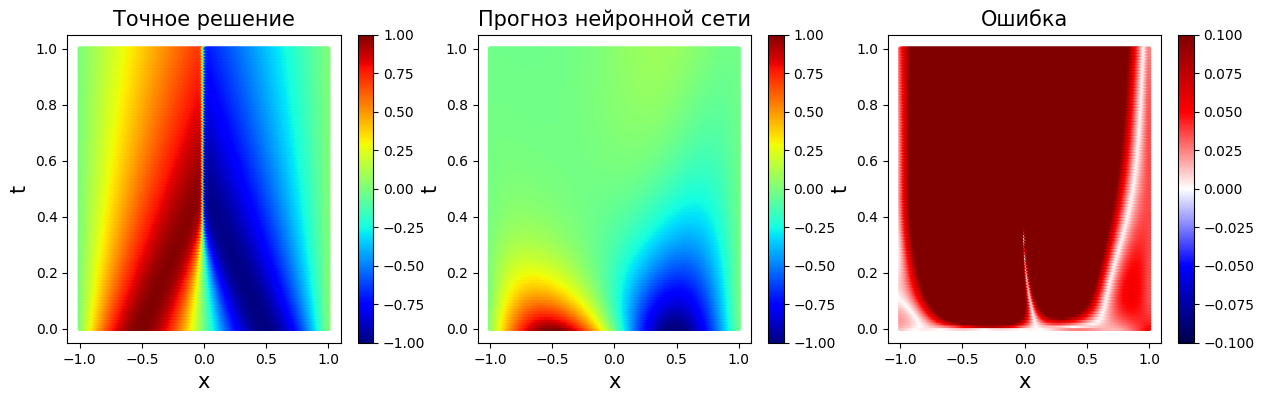

In [24]:
fig = plt.figure(figsize=[15,4])
axes = fig.subplots(1,3, sharex=False, sharey=False)
img1 = axes[0].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star, cmap='jet', vmax=1, vmin=-1, s=5)
axes[0].set_title('Точное решение', fontsize=15)
axes[0].set_xlabel('x', fontsize=15)
axes[0].set_ylabel('t', fontsize=15)
plt.colorbar(img1, ax=axes[0])
img2 = axes[1].scatter(X_star[:, 0:1], X_star[:, 1:2], 
                       c=u_star_pred_NN, cmap='jet', 
                       vmax=1, vmin=-1, s=5)
axes[1].set_title('Прогноз нейронной сети', fontsize=15)
axes[1].set_xlabel('x', fontsize=15)
axes[1].set_ylabel('t', fontsize=15)
plt.colorbar(img2, ax=axes[1])
img3 = axes[2].scatter(
    X_star[:, 0:1], X_star[:, 1:2], 
    c=np.abs(u_star.flatten()-u_star_pred_NN.flatten()), 
    cmap='seismic', vmax=0.1, vmin=-0.1, s=5
)
axes[2].set_title('Ошибка', fontsize=15)
axes[2].set_xlabel('x', fontsize=15)
axes[2].set_ylabel('t', fontsize=15)
plt.colorbar(img3, ax=axes[2]);

## Нейронные сети PINN

Нейронные сети на основе физики (с физической информацией) (Physics-informed neural networks, PINN) представляют собой  универсальные аппроксиматоры функций, которые могут встраивать знание физических законов, управляющих исходными данных и описываемых дифференциальными уравнениями с частными производными (PDE), в процесс обучения. Низкая доступность данных для некоторых биологических и инженерных задач ограничивает надежность обычных моделей машинного обучения, используемых для этих приложений. Априорное знание физических законов действует при обучении нейронных сетей (NN) как регуляризация, которая ограничивает пространство допустимых решений, увеличивая обобщаемость аппроксимации функции. Таким образом, встраивание этой априорной информации в нейронную сеть приводит к повышению информационного содержания доступных данных, облегчая алгоритму нейронной сети изучение правильного решения и хорошее обобщение даже при небольшом количестве обучающих данных.

Если в области $\Omega\subset\mathbb{R}^{n}$ задано уравнение с частными производными 

$$\mathscr{D}\left[\mathbf{u}\right]=0,\,\mathbf{x}\in\Omega \tag{1}$$ 

с граничными условиями

$$\mathscr{B}\left[\mathbf{u}\right]=0,\,\mathbf{x}\in\partial\Omega, \tag{2}$$

то для приближенного решения краевой задачи (1)-(2) можно построить и обучить нейронную сеть с выходом $y\left(\mathbf{x};\,\boldsymbol{\theta}\right)$, где $\mathbf{x}\in\bar{\Omega}$ – входные значения, $\boldsymbol{\theta}\in\mathbb{R}^{p}$ – вектор параметров (весов и смещений) нейронной сети, которая бы аппроксимировала решение (1)-(2):

$$u\left(\mathbf{x}\right)\approx y\left(\mathbf{x};\,\boldsymbol{\theta}\right),\mathbf{x}\in\bar{\Omega},\boldsymbol{\theta}\in\mathbb{R}^{p}.$$

Такая нейронная сеть обучается с использованием алгоритма градиентного спуска при помощи минимизации некоторого функционала потерь, который оценивает отклонение нейросетевой аппроксимации $y\left(\mathbf{x};\boldsymbol{\theta}\right)$ от точного решения $u\left(\mathbf{x}\right)$ рассматриваемой краевой задачи (1)-(2). Общая схема обучения нейронной сети на основе физики показана на рис. ниже.

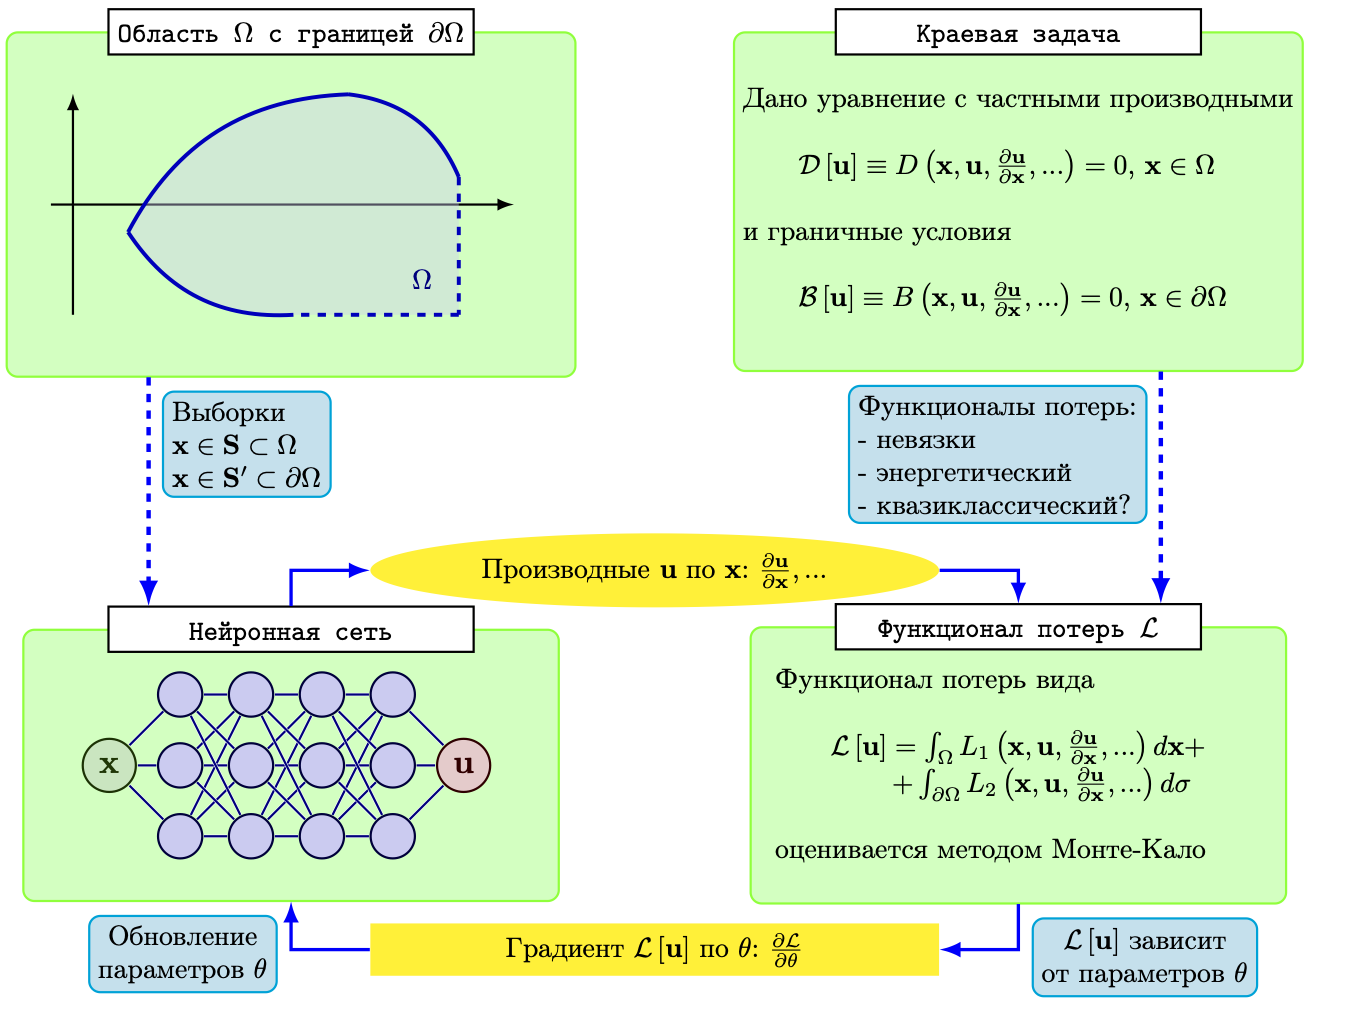

В качестве функционала потерь часто используется функционал метода наименьших квадратов (функционал невязки), который для краевой задачи (1)–(2) обычно записывается в виде

$$J\left[\mathbf{u}\right]=\intop_{\Omega}\left|\mathscr{D}\left[\mathbf{u}\right]\right|^{2}d\mathbf{x}+\intop_{\partial\Omega}\left|\mathscr{B}\left[\mathbf{u}\right]\right|^{2}d\sigma$$

Для оценки интегралов, входящих в функционал потерь, в машинном обучении обычно применяется метод интегрирования Монте-Карло, а для нахождения частных производных, входящих в функционал, применяется алгоритм автоматического дифференцирования. 

В методе интегрирования Монте-Карло интеграл вида

$$I=\intop_{\mathbf{X}}f\left(\mathbf{x}\right)\,\rho\left(\mathbf{x}\right)d\mathbf{x},$$

где $\rho\left(\mathbf{x}\right)$ – плотность некоторого вероятностного распределения в области $\mathbf{X}$, аппроксимируется конечной суммой

$$I\approx\hat{I}_{n}=\frac{1}{n}\sum_{i=1}^{n}f\left(\mathbf{x}_{i}\right),$$

где $\left\{ \mathbf{x}_{i}\right\} _{i=1}^{n}$ – случайная выборка точек из области $\mathbf{X}$ с плотностью распределения $\rho\left(\mathbf{x}\right)$. 

Метод интегрирования Монте-Карло активно применяется в машинном обучении, так как он позволяет избежать застревания в локальных минимумах при обучении нейронной сети.

## Аппроксимация функций

Большинство физических законов, управляющих динамикой физической системы, можно описать с помощью уравнений в частных производных. Например, уравнения Навье–Стокса представляют собой набор уравнений в частных производных, выведенных из законов сохранения (то есть сохранения массы, импульса и энергии), которые управляют механикой жидкости. Решение уравнений Навье–Стокса с соответствующими начальными и граничными условиями позволяет количественно оценить динамику потока в точно определенной геометрии. Однако эти уравнения не могут быть решены точно, поэтому необходимо использовать численные методы (конечные разности, конечные элементы и пр.). В этой ситуации эти управляющие уравнения должны быть решены с учетом предыдущих предположений, линеаризации и адекватной дискретизации по времени и пространству.

В последнее время решение управляющих уравнений в частных производных физических явлений с использованием глубокого обучения стало новой областью научного машинного обучения (SciML), использующей теорему универсальной аппроксимации и высокую выразительность нейронных сетей. В целом, глубокие нейронные сети могут аппроксимировать любую многомерную функцию при условии предоставления достаточных данных для обучения. Однако такие сети не учитывают физические характеристики, лежащие в основе задачи, и уровень точности аппроксимации, обеспечиваемый ими, по-прежнему сильно зависит от тщательной спецификации геометрии проблемы, а также начальных и граничных условий. Без этой предварительной информации решение не является единственным и может потерять физическую корректность. С другой стороны, нейронные сети, основанные на физике (PINN), используют физические уравнения при обучении нейронных сетей. А именно, PINN предназначены для обучения с целью удовлетворения заданных обучающих данных, а также наложенных физических уравнений. Таким образом, нейронная сеть может руководствоваться обучающими данными, которые не обязательно должны быть большими и полными. Потенциально точное решение уравнений с частными производными может быть найдено без знания граничных условий. Поэтому, имея некоторые знания о физических характеристиках задачи и некоторую форму обучающих данных (даже разреженных и неполных), PINN может использоваться для поиска оптимального решения с высокой точностью.

PINN позволяют решать широкий спектр проблем в вычислительной науке и представляют собой новаторскую технологию, ведущую к разработке новых классов численных решений для дифференциальных уравнений. PINN можно рассматривать как альтернативу традиционным подходам и как новые подходы, основанные на данных, для обращения моделей и идентификации систем. В частности, обученная сеть PINN может использоваться для прогнозирования значений на сетках моделирования с различным разрешением без необходимости повторного обучения. Кроме того, сети PINN позволяют использовать автоматическое дифференцирование (AD) для вычисления требуемых производных в частных дифференциальных уравнениях, причем автоматическое дифференцирование  превосходит численное или символьное дифференцирование при обучении нейронных сетей.

## Сети PINN для обыкновенных дифференциальных уравнений

### Пример: обыкновенное дифференциальное уравнение 1го порядка
$y'(x)+y(x)=0 \hspace{0.3cm} при \hspace{0.3cm} 0 < x < 4 $
            
$y(0)=1$

*Точное решение:  $y(x)=\exp(-x)$*


### Построение сети PINN

In [25]:
class ODE_1st(tf.keras.Model):
    def train_step(self, data):
        # точки из области определения решения и аналитические 
        # (точные) решения в этих точках
        x, y_exact = data
        # начальные условия для PINN
        x0       = tf.constant([0.0], dtype=tf.float32)
        y0_exact = tf.constant([1.0], dtype=tf.float32)
        # вычисляем градиенты и обновляем веса и смещение
        with tf.GradientTape() as tape:
            # вычисляем градиент dy/dx
            with tf.GradientTape() as tape2:
              tape2.watch(x0)
              tape2.watch(x)
              y0_NN = self(x0, training=True)
              y_NN  = self(x, training=True)
            dy_dx_NN= tape2.gradient(y_NN,x)
            # Потери = ОДУ + граничные/начальные условия
    # model.compute_loss(x, y, y_pred, sample_weight, training) = MSE
            loss = self.compute_loss(x,  dy_dx_NN, -y_NN)\
                 + self.compute_loss(x0, y0_NN, y0_exact)  
        gradients = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_weights)
        )

        for metric in self.metrics:
            metric.update_state(y_exact, y_NN)

        return {m.name: m.result() for m in self.metrics}

### Обучение сети PINN

In [26]:
n_train = 20
xmin = 0
xmax = 4

# область определения решения
x_train = np.linspace(xmin,xmax,n_train)

# точное решение y(x) для оценки качества обучения модели
y_train = tf.exp(-x_train)

# входные и выходные нейроны
input_neurons  = 1
output_neurons = 1

# гиперпараметры
epochs = 40

# определение модели
activation = 'elu'
input = Input(shape=(input_neurons,))
x = Dense(50, activation=activation)(input)
x = Dense(50, activation=activation)(x)
x = Dense(50, activation=activation)(x)
output = Dense(output_neurons,activation=None)(x)
model = ODE_1st(input,output)

# определения потерь, метрики и оптимизатора 
loss      = keras.losses.MeanSquaredError()
metrics   = keras.metrics.MeanSquaredError()
optimizer = Adam(learning_rate=0.001)

model.compile(loss=loss, optimizer=optimizer, metrics=[metrics])
model.summary()

Model: "ode_1st"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,251 (20.51 KB)

 Trainable params: 5,251 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(x_train, y_train,batch_size=1,epochs=epochs)

Epoch 1/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - mean_squared_error: 0.1719 - loss: 0.3791
Epoch 2/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - mean_squared_error: 0.0408 - loss: 0.7786
Epoch 3/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - mean_squared_error: 0.0257 - loss: 0.3865
Epoch 4/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - mean_squared_error: 0.0076 - loss: 0.5454
Epoch 5/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - mean_squared_error: 0.0037 - loss: 0.5210
Epoch 6/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - mean_squared_error: 6.0946e-04 - loss: 0.5304
Epoch 7/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - mean_squared_error: 0.0012 - loss: 0.4339
Epoch 8/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - mean_squared_error: 0.0018 - loss: 0.4594
Epoch 9/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - mean_squared_error: 7.9249e-04 - loss: 0.5009
Epoch 10/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - mean_squared_error: 9.8004e-04 - loss: 0.4826
Epoch 11/40
20/20 ━━━━━━━━━━━━━━━━━━━

### Эволюция потерь в ходе обучения

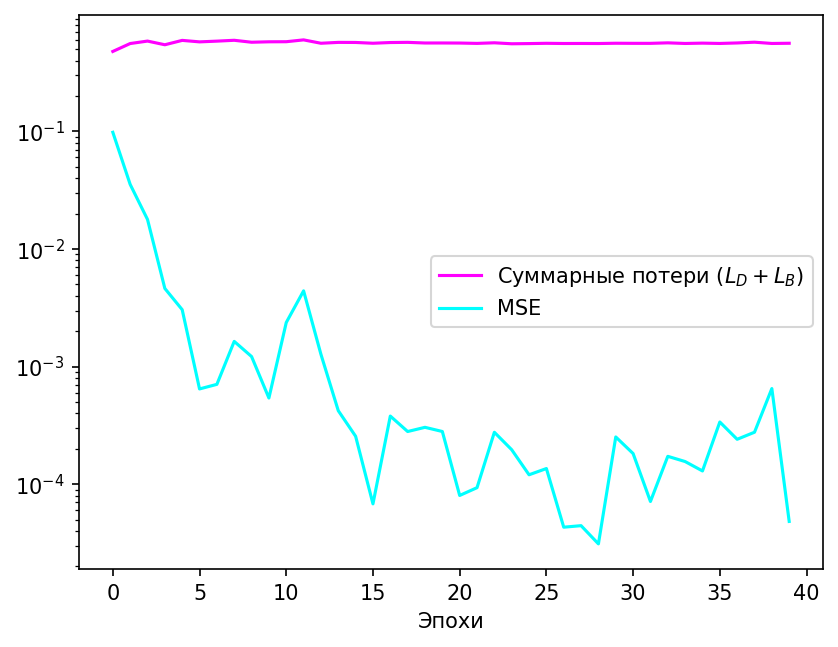

In [28]:
# история обучения для потерь и метрики
plt.rcParams['figure.dpi'] = 150
plt.plot(history.history['loss'],color='magenta',
         label='Суммарные потери ($L_D + L_B$)')
plt.plot(history.history['mean_squared_error'],color='cyan',label='MSE')
plt.yscale("log")
plt.xlabel('Эпохи')
plt.legend(loc='center right')
plt.show()

### Решение и его производные

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


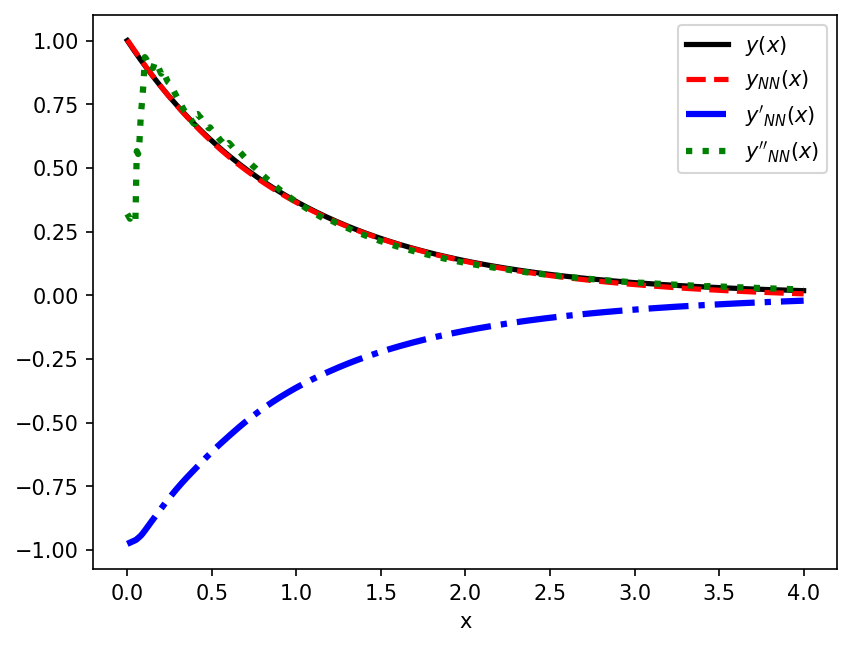

In [29]:
# Проверка PINN в различных точках не из обучающего набора
n = 500
x = np.linspace(0,4,n)
y_exact = tf.exp(-x)
y_NN = model.predict(x)

# производные y'(x) и y''(x) от выхода модели
x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
with tf.GradientTape(persistent=True) as t:
  t.watch(x_tf)
  with tf.GradientTape(persistent=True) as t2:
        t2.watch(x_tf)
        y = model(x_tf)
  dy_dx_NN = t2.gradient(y, x_tf)
d2y_dx2_NN = t.gradient(dy_dx_NN, x_tf)
del t, t2

# рисуем результаты
plt.rcParams['figure.dpi'] = 150
plt.plot(x, y_exact, color="black",linestyle='solid',
                     linewidth=2.5,label="$y(x)$")
plt.plot(x, y_NN, color="red",linestyle='dashed',
                     linewidth=2.5, label="$y_{NN}(x)$")
plt.plot(x, dy_dx_NN, color="blue",linestyle='-.',
                     linewidth=3.0, label="$y'_{NN}(x)$")
plt.plot(x, d2y_dx2_NN, color="green", linestyle='dotted',
                     linewidth=3.0, label="$y''_{NN}(x)$")
plt.legend()
plt.xlabel("x")
plt.show()

В этом примере функция потерь задавалась в методе `compile()` как `keras.losses.MeanSquaredError()` и вызывалась в методе `train_step()` класса `ODE_1st` через вызов метода `compute_loss()`.

Метод `compute_loss()` также можно переопределить, как это сделано в следующем примере:
```python
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import tensorflow as tf

class MyModel(Model):
    def __init__(self, *args, **kwargs):
        super(MyModel, self).__init__(*args, **kwargs)
        self.loss_tracker = tf.keras.metrics.Mean(name='loss')
        
    def compute_loss(self, x, y, y_pred, sample_weight):
        loss = tf.reduce_mean(tf.math.squared_difference(y_pred, y))
        loss += tf.add_n(self.losses)
        self.loss_tracker.update_state(loss)
        return loss
        
    def reset_metrics(self):
        self.loss_tracker.reset_states()
        
    @property
    def metrics(self):
        return [self.loss_tracker]
        
tensors = tf.random.uniform((10, 10)), tf.random.uniform((10,))
dataset = tf.data.Dataset.from_tensor_slices(tensors).repeat().batch(1)
inputs = tf.keras.layers.Input(shape=(10,), name='my_input')
outputs = tf.keras.layers.Dense(10)(inputs)
model = MyModel(inputs, outputs)
model.add_loss(tf.reduce_sum(outputs))
optimizer = tf.keras.optimizers.SGD()
model.compile(optimizer, loss='mse', steps_per_execution=10)
model.fit(dataset, epochs=2, steps_per_epoch=10)
print('My custom loss: ', model.loss_tracker.result().numpy())
```